[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/deijany/DSP2023-2023117048_ICCT2024-KT2153/blob/main/linearizer_ICCT_2024.ipynb)

# Digital Linearizer Based on 1-Bit Quantizations — ICCT 2024

This notebook implements the **matrix-inversion linearizer** from the following papers:

> **[DSP 2023]** D. Rodriguez Linares and H. Johansson, "Low-Complexity Memoryless Linearizer for Analog-to-Digital Interfaces," *24th International Conference on Digital Signal Processing (DSP)*, 2023.
> [[IEEE]](https://ieeexplore.ieee.org/document/10167765/) · [[arXiv]](https://arxiv.org/abs/2304.05849)

> **[ICCT 2024]** D. Rodriguez Linares and H. Johansson, "Digital Linearizer Based on 1-Bit Quantizations," *24th IEEE International Conference on Communication Technology (ICCT)*, 2024.
> [[IEEE]](https://ieeexplore.ieee.org/document/10946352/) · [[arXiv]](https://arxiv.org/abs/2503.02729)

The linearizer suppresses **nonlinear distortion emanating from analog frontends** — including ADCs and the components that precede them (filters, amplifiers, and mixers) — without requiring the analog frontend itself to be modified.

---

### Problem statement

Let $x(n)$ be the desired signal and $v(n)$ its distorted version after passing through the analog frontend:

$$v(n) = a_0 + a_1 x(n) + \sum_{p=2}^{P} a_p \, x^p(n)$$

The linearizer reconstructs the clean signal as:

$$\hat{x}(n) = c_0 + c_1 v(n) + \sum_{m=1}^{N} w_m \, f_m\!\bigl(v(n) + b_m\bigr)$$

where:
- $f_m(\cdot)$ is the **activation function** — ABS and ReLU were studied in [DSP 2023]; Q1b (1-bit) is the focus of [ICCT 2024]
- $b_m$ are **offset thresholds (bias)**
- $w_m$ are **weights**, solved in closed form via regularized matrix inversion

### Key innovation: 1-bit activations (ICCT 2024)

When $f_m$ is the **1-bit quantization** (Q1b): $f_m(u) = 1$ if $u \ge 0$, else $0$, the weights $w_m$ multiply binary values only. Combined with uniformly spaced offsets $b_m = -1 + \tfrac{2m}{N+1}$, the entire linearizer reduces to a **look-up table** — eliminating all multiplications in the inference path.

### Matrix inversion based solution (Solver)

$$\mathbf{w} = \left(\Phi^\top \Phi + \lambda I\right)^{-1} \Phi^\top (x - v)$$

where $\Phi = [\phi(v+b_1), \ldots, \phi(v+b_N), v, \mathbf{1}]$ and $\lambda$ is the L2 regularization constant.

The offset $b_m$ grid is selected by **linesearch**: the best candidate is chosen by the **worst-case SNR** across all training signals (minimax criterion).

> **Polynomial (Hammerstein) note**: setting $f_m(v) = [v^2, v^3, \ldots, v^n]$ with $b_m = 0$ gives the classical Hammerstein structure; only 1 simulation is needed since the offsets are fixed.

In [1]:
# Colab setup — runs only when executed on Google Colab
import sys, os

if 'google.colab' in sys.modules:
    !git clone https://github.com/deijany/DSP2023-2023117048_ICCT2024-KT2153.git
    os.chdir('DSP2023-2023117048_ICCT2024-KT2153')
    !pip install -q h5py


## 1. Imports

In [2]:
from classes.file_manipulation import PathManager, DataSetLoader, DataSetWriter
from classes.generator_classes_v4 import PolynomialSignalGenerator
from myfunctions.functions_helper import SpectrumAnalyzer, store_dictionary, print_snr_summary
from classes.linearizers_classes import MatrixInversionLinearizer, ActivationFunctions
from classes.signal_processing import Statistics, SNR
import numpy as np

np.random.seed(1)

## 2. Configuration

### 2.1 Dataset

| Parameter | Value | Description |
|---|---|---|
| `amount_signals` | 100 | Total multisine signals generated |
| `amount_sinusoids_per_signal` | 31 | Active subcarriers per signal |
| `polynomial_order` | 9 | PA nonlinearity order |
| `amount_bits` | 8 | ADC resolution applied to distorted signal $v$ |
| `frequency_dependent_case` | False | coefficients are frequency-independent |
| `storage_dataset` | False | Set `True` to regenerate and overwrite dataset on disk |

In [3]:
dataset_features = {
    'amount_signals': 100,
    'amount_sinusoids_per_signal': 31,
    'polynomial_order': 9,
    'number_samples_signal': int(np.power(2, 13)),
    'amount_bits': 8,
    'frequency_dependent_case': False,
}
dataset_version = 1
storage_dataset = False  # set True to regenerate dataset from scratch

### 2.2 Linearizer

| Parameter | Value | Description                                                                             |
|---|---|-----------------------------------------------------------------------------------------|
| `activation_function` | `ReLU` | Branch nonlinearity — change to: `ABS`, `ReLU`, `Q1b`, `linear`, `polynomial`           |
| `branch_number` | 7 | Number of parallel branches (model width)                                               |
| `output_resolution` | 12 | Output quantizer resolution (bits)                                                      |
| `internal_resolution` | 1000 | Internal quantizer (1000 ≈ no quantization)                                             |
| `L2` | 1e-10 | Ridge regularization for matrix inversion                                               |
| `number_simulations` | 10 | Candidate $b_k$ initializations (polynomial always runs 1 since in Hammerstein $b_k=0$) |

In [4]:
activation_function = ActivationFunctions.ReLU  # change here: ABS, ReLU, Q1b, linear, polynomial (Hammerstein linearizer, bias=0)
activation_name = activation_function.__name__

branch_number = 7
output_resolution = 12
internal_resolution = 1000
L2 = 1e-10
number_simulations = 10
plotting = True
store_training = True

## 3. Signal Generation

Multisine signals $x$ are generated as sums of sinusoids with random phases and normalized to $[-0.94, 0.94]$ (leaving headroom before full-scale ADC clipping).

The analog frontend distortion model applies a frequency-independent polynomial nonlinearity followed by ADC quantization:

$$v(n) = \text{ADC}\!\left(\sum_{k=1}^{P} a_k \cdot x^k(n)\right)$$

This models the combined effect of nonlinearities from the ADC and the analog components (filters, amplifiers, mixers) that precede it.

In [5]:
signals = PolynomialSignalGenerator(dataset_features, seed_value=7)
X, _, _ = signals.generate_multisine()
X = X / np.max(abs(X), axis=1)[:, np.newaxis]  # normalize each signal
X = X * 0.94                                    # back-off from full scale
V, nonlinear_coefficients = signals.generate_distorted_signals(X)

print(f'X shape: {X.shape}  range: [{X.min():.3f}, {X.max():.3f}]')
print(f'V shape: {V.shape}  range: [{V.min():.3f}, {V.max():.3f}]')

X shape: (100, 8192)  range: [-0.940, 0.940]
V shape: (100, 8192)  range: [-0.723, 0.988]


## 4. Dataset — Save / Load

Signals are split into **train (10%)** and **test (90%)** sets and stored as HDF5 files.

Set `storage_dataset = True` in Section 2.1 to regenerate from scratch. Otherwise the stored dataset is loaded.

In [6]:
folder_prefix = 'v' + str(dataset_version)
current_path, _ = PathManager().check_path_by_host()
dataset_path = ('v' + str(dataset_version) + '_f' + 'freq_dep' + '0_ord_'
                + str(dataset_features['amount_bits']) + 'bits_'
                + str(dataset_features['polynomial_order'] + 1) + 'terms')
train_path, test_path = PathManager().make_path(root_path=current_path, local_path='datasets',
                                                 current_path=dataset_path, state='data')
simulation_path = PathManager().make_path(root_path=current_path, local_path='trained_model',
                                           current_path=folder_prefix, state='simulations')
if storage_dataset:
    train_percent = 0.1
    dataset = DataSetWriter(dataset_features, train_path, test_path, train_pct=train_percent)
    dataset.write_dataset(V, X, nonlinear_coefficients)
    print('New dataset saved.')
else:
    print('Using stored dataset.')

/Users/clotus/dataloc/git_local/codes/public/DSP2023_ICCT2024/trained_model/v1
Using stored dataset.


In [7]:
loader1 = DataSetLoader(path=train_path)
data1 = loader1.load_dataset()
X_train = data1['pure_signal']
V_train = data1['distorted_signal']

loader2 = DataSetLoader(path=test_path)
data2 = loader2.load_dataset()
X_test = data2['pure_signal']
V_test = data2['distorted_signal']

print(f'Train: {X_train.shape[0]} signals  |  Test: {X_test.shape[0]} signals')

Train: 10 signals  |  Test: 90 signals


## 5. SNR Baselines

Two reference SNRs are computed before training:

- **SNR(X, X_quant)** — quantization noise floor: ideal ADC applied to the clean signal, no PA distortion. This is the upper bound the linearizer can approach.
- **SNR(X, V)** — combined PA distortion + quantization noise. This is where we start.

The linearizer gain = SNR(X, X̂) − SNR(X, V).

In [8]:
X_train_quant = PolynomialSignalGenerator.quantize(X_train, dataset_features['amount_bits'])
X_test_quant  = PolynomialSignalGenerator.quantize(X_test,  dataset_features['amount_bits'])

SNR_array_X_test  = SNR(X_test,  X_test_quant,  remove_DC=True, grouping_method=None).result
SNR_array_V_test  = SNR(X_test,  V_test,        remove_DC=True, grouping_method=None).result
SNR_array_X_train = SNR(X_train, X_train_quant, remove_DC=True, grouping_method=None).result
SNR_array_V_train = SNR(X_train, V_train,       remove_DC=True, grouping_method=None).result

print(f'Train  quantization SNR (upper bound): {np.mean(SNR_array_X_train):.2f} dB')
print(f'Train  distorted    SNR (starting pt): {np.mean(SNR_array_V_train):.2f} dB')
print(f'Test   quantization SNR (upper bound): {np.mean(SNR_array_X_test):.2f} dB')
print(f'Test   distorted    SNR (starting pt): {np.mean(SNR_array_V_test):.2f} dB')

Train  quantization SNR (upper bound): 43.22 dB
Train  distorted    SNR (starting pt): 25.34 dB
Test   quantization SNR (upper bound): 42.73 dB
Test   distorted    SNR (starting pt): 25.11 dB


## 6. Training

The weights $\mathbf{a}_k$ are computed in closed form by solving the regularized least-squares problem:

$$\mathbf{a}_k = \left(\Phi^\top \Phi + \lambda I\right)^{-1} \Phi^\top (x - v)$$

where $\Phi$ is the branch matrix $[\phi(v+b_k),\; v,\; \mathbf{1}]$ and $\lambda$ is the L2 regularization constant.

The offset $b_k$ is selected by **linesearch** over `number_simulations` candidates. The best is chosen by the **worst-case SNR** across all training signals (minimax criterion — protects every signal, not just the average).

> **Polynomial note**: since $b_k = 0$ always for polynomial, only 1 simulation is run.

In [9]:
linearizer = MatrixInversionLinearizer(
    X_train, V_train, branch_number, activation_function,
    number_simulations, L2,
    output_quantizer_resolution=output_resolution,
    internal_quantizer_resolution=internal_resolution
)
ak, bk, _, _ = linearizer.train()

branch_number: 7   Init_numb: 1 / 10  best_error: 0.090452  best_SNR: 39.16362  current_SNR: 39.16362
branch_number: 7   Init_numb: 2 / 10  best_error: 0.08878  best_SNR: 39.47265  current_SNR: 39.47265
branch_number: 7   Init_numb: 3 / 10  best_error: 0.08878  best_SNR: 39.47265  current_SNR: 39.08723
branch_number: 7   Init_numb: 4 / 10  best_error: 0.08878  best_SNR: 39.47265  current_SNR: 38.40949
branch_number: 7   Init_numb: 5 / 10  best_error: 0.08878  best_SNR: 39.47265  current_SNR: 37.59197
branch_number: 7   Init_numb: 6 / 10  best_error: 0.08878  best_SNR: 39.47265  current_SNR: 36.74182
branch_number: 7   Init_numb: 7 / 10  best_error: 0.07519  best_SNR: 39.77571  current_SNR: 39.77571
branch_number: 7   Init_numb: 8 / 10  best_error: 0.079857  best_SNR: 40.63285  current_SNR: 40.63285
branch_number: 7   Init_numb: 9 / 10  best_error: 0.079857  best_SNR: 40.63285  current_SNR: 39.41957
branch_number: 7   Init_numb: 10 / 10  best_error: 0.079857  best_SNR: 40.63285  current

## 7. Prediction

Apply the trained weights to both train and test sets.

> **Note**: if you sweep L2, re-initialize the linearizer with the best L2 before calling `predictor`, since the training loop leaves it pointing to the last L2 tried.

In [10]:
X_hat_test_MI,  _, _ = linearizer.predictor(X_test,  V_test,  ak, bk)
X_hat_train_MI, _, _ = linearizer.predictor(X_train, V_train, ak, bk)

SNR_array_X_hat_train_MI = SNR(X_train, X_hat_train_MI, remove_DC=True, grouping_method=None).result
SNR_array_X_hat_test_MI  = SNR(X_test,  X_hat_test_MI,  remove_DC=True, grouping_method=None).result

## 8. Results

The table below compares SNR before (V) and after (X̂) linearization against the quantization upper bound (X).
- **min** = worst-case signal
- **mean** = average across all signals
- **max** = best-case signal

In [11]:
print_snr_summary(
    X_train, V_train, X_hat_train_MI, SNR_array_X_train, SNR_array_V_train, SNR_array_X_hat_train_MI,
    X_test,  V_test,  X_hat_test_MI,  SNR_array_X_test,  SNR_array_V_test,  SNR_array_X_hat_test_MI,
    X, V, ak, L2, bk
)

dictionary = {
    'activation':              activation_name,
    'branch_number':           branch_number,
    'L2':                      L2,
    'ak':                      ak,
    'bk':                      bk,
    'SNR_V_test':              np.mean(SNR_array_V_test),
    'SNR_X_test':              np.mean(SNR_array_X_test),
    'SNR_X_hat_test_MI':       np.mean(SNR_array_X_hat_test_MI),
    'SNR_V_train':             np.mean(SNR_array_V_train),
    'SNR_X_train':             np.mean(SNR_array_X_train),
    'SNR_X_hat_train_MI':      np.mean(SNR_array_X_hat_train_MI),
    'variance_x_hat_SNR':      Statistics.variance(SNR_array_X_hat_test_MI),
    'std_deviation_x_hat_SNR': Statistics.std_deviation(SNR_array_X_hat_test_MI),
}

------------------------------------------------------------
-------------------------Prediction-------------------------
Train X:           ( 10  signals)  min: 42.07  mean: 43.22  max: 44.65
Train V:           ( 10  signals)  min: 24.03  mean: 25.34  max: 26.27
Train MI:          ( 10  signals)  min: 40.69  mean: 41.26  max: 42.17
-----------------------------------
Test X:            ( 90  signals)  min: 40.02  mean: 42.73  max: 44.44
Test V:            ( 90  signals)  min: 22.94  mean: 25.11  max: 26.57
Test MI:            ( 90  signals)  min: 39.04  mean: 40.88  max: 42.14
------------------------------------------------------------
X: [-0.94, 0.94]  V: [-0.72, 0.99]  X_hat_train: [-0.91, 0.94]  X_hat_test: [-0.91, 0.94]
ak: max--> 1.521203753023889   L2: 1e-10   bk_max: 0.65


## 9. Spectrum Plots

Each plot shows the amplitude spectrum of one test signal **before** (distorted $v$) and **after** (linearized $\hat{x}$) processing.

A Blackman-Harris window is applied before the FFT to reduce spectral leakage. The y-axis is normalized relative to the signal peak, so 0 dB = signal level and the noise floor shows how much distortion was removed.

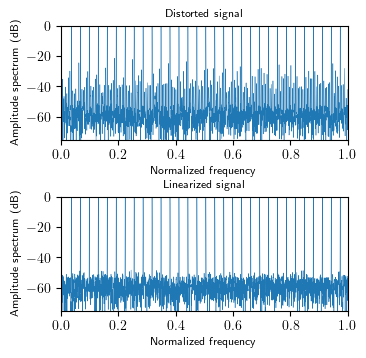

In [12]:
if plotting:
    title = ['Distorted signal', 'Linearized signal']
    for pos in range(0, len(V_test), 4000):
        x = np.expand_dims(X_hat_test_MI[pos], axis=0)
        v = np.expand_dims(V_test[pos], axis=0)
        SpectrumAnalyzer().plot_frequency_domain(
            [v, x], title, window_type='Blackmanharris',
            save_path='./plots/' + activation_name + '_multisine_' + str(internal_resolution) + 'Ibits_' + str(output_resolution) + 'Obits',
            save_fig=True
        )

## 10. Save Results

In [13]:
if store_training:
    base_filename = (simulation_path + '/' + str(folder_prefix) + '_' + activation_name + '_ord_' + str(0)
                     + '_quant_' + str(internal_resolution) + 'Ibits_' + str(output_resolution) + 'Obits')
    store_dictionary(base_filename, dictionary)
    print(f'Results saved to: {base_filename}.pickle')
else:
    print('Training was not saved.')

Results saved to: /Users/clotus/dataloc/git_local/codes/public/DSP2023_ICCT2024/trained_model/v1/v1_ReLU_ord_0_quant_1000Ibits_12Obits.pickle
